In [ ]:
# ACCRA TECHNICAL UNIVERSITY

## Department of Computer Science

### BCS 404: Introduction to Data Science with Python

# Exploratory Data Analysis, Statistical Analysis and Machine Learning using the Titanic Dataset

Student Name: Koomson Baafi Alexander

Index Number: 01258375B

Lecturer: Dr. Joseph Dadzie

Academic Year: 2025/2026 Second Semester

In [ ]:
# Introduction

The Titanic dataset is one of the most widely used datasets in data science and machine learning for binary classification problems. It contains demographic, socioeconomic, and travel information about passengers aboard the RMS Titanic, along with their survival status. This project applies Python libraries such as Pandas, NumPy, Matplotlib, Seaborn, and Scikit-learn to perform exploratory data analysis, statistical analysis, and machine learning. The objective is to identify patterns in the data and develop a Logistic Regression model capable of predicting passenger survival.

In [ ]:
# Dataset Description

The dataset used in this project was obtained from the Kaggle Titanic Competition. It contains information on 891 passengers and 12 variables, including passenger demographics, ticket information, passenger class, fare, family relationships, and survival status. The target variable is **Survived**, where 0 indicates that the passenger did not survive and 1 indicates that the passenger survived.

In [4]:
%pip install seaborn

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
# Task 1: Data Acquisition

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# Display dataset dimensions
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 891
Number of Columns: 12


In [7]:
# Display column names
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')


In [8]:
# Display data types
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [ ]:
### Interpretation

The Titanic dataset was successfully imported into Python. It contains **891 observations** and **12 variables**, including passenger demographics, ticket information, passenger class, fare, age, and survival status. The variables consist of both numerical and categorical data types, making the dataset suitable for exploratory data analysis, statistical analysis, and machine learning.

In [ ]:
# Question 2: Data Cleaning

In [9]:
# Check for missing values
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_values

,Missing Values,Percentage
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


In [ ]:
### Interpretation

The dataset contains missing values in the **Age**, **Cabin**, and **Embarked** variables. Approximately **19.87%** of the values in the Age column are missing, **77.10%** of the Cabin values are missing, and **0.22%** of the Embarked values are missing. These missing values must be handled before performing statistical analysis and building machine learning models.

In [10]:
# Create a copy of the dataset
clean_df = df.copy()

# Fill missing Age values with the median
clean_df["Age"] = clean_df["Age"].fillna(clean_df["Age"].median())

# Fill missing Embarked values with the mode
clean_df["Embarked"] = clean_df["Embarked"].fillna(clean_df["Embarked"].mode()[0])

# Drop Cabin because of excessive missing values
clean_df = clean_df.drop(columns=["Cabin"])

print("Missing values after cleaning:")
print(clean_df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [ ]:
### Preprocessing Decisions

The missing values in the **Age** column were replaced using the median because the median is less affected by extreme values than the mean. The **Embarked** column was filled using the mode since it is a categorical variable with only two missing values. The **Cabin** column was removed because more than 77% of its values were missing, making it unsuitable for reliable analysis.

In [11]:
# Check for duplicate observations
duplicates = clean_df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [12]:
# Remove duplicates if they exist
clean_df = clean_df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:")
print(clean_df.shape)

Dataset Shape After Removing Duplicates:
(891, 11)


In [ ]:
### Interpretation

The dataset was checked for duplicate observations. If duplicate records were present, they were removed to ensure that each passenger record was unique. Removing duplicate observations helps improve data quality and prevents bias during statistical analysis and machine learning.

In [ ]:
# Question 3: Data Visualization

## 1. Histogram of Passenger Ages

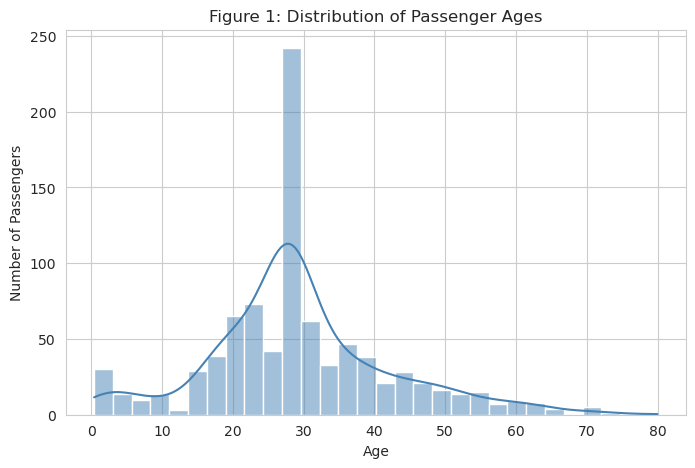

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(clean_df["Age"], bins=30, kde=True, color="steelblue")

plt.title("Figure 1: Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

In [ ]:
### Interpretation

The histogram shows that most passengers were between **20 and 40 years** of age. There were relatively fewer children and elderly passengers. The distribution is slightly right-skewed, indicating that the majority of passengers were young adults.

In [ ]:
## 2. Passenger Class Distribution

<ipython-input-14-447c59e15639>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Pclass", data=clean_df, palette="viridis")


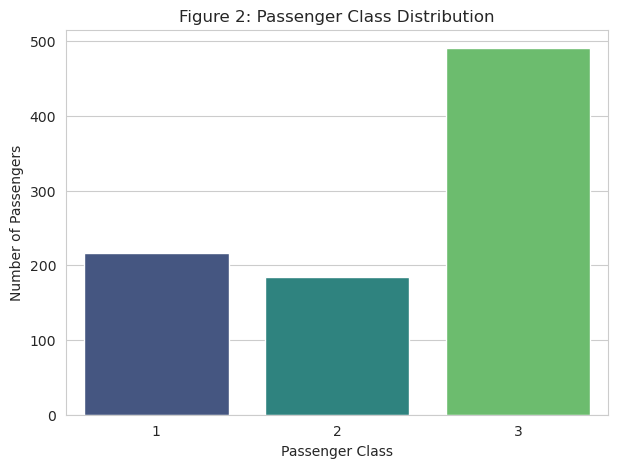

In [14]:
plt.figure(figsize=(7,5))

sns.countplot(x="Pclass", data=clean_df, palette="viridis")

plt.title("Figure 2: Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

In [ ]:
### Interpretation

The chart shows that **Third Class** had the highest number of passengers, followed by **First Class**, while **Second Class** had the fewest passengers. This indicates that most passengers travelled in the lower-class section of the ship.

In [ ]:
## 3. Boxplot of Age by Passenger Class

<ipython-input-15-d36c4913d71e>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Pclass", y="Age", data=clean_df, palette="Set2")


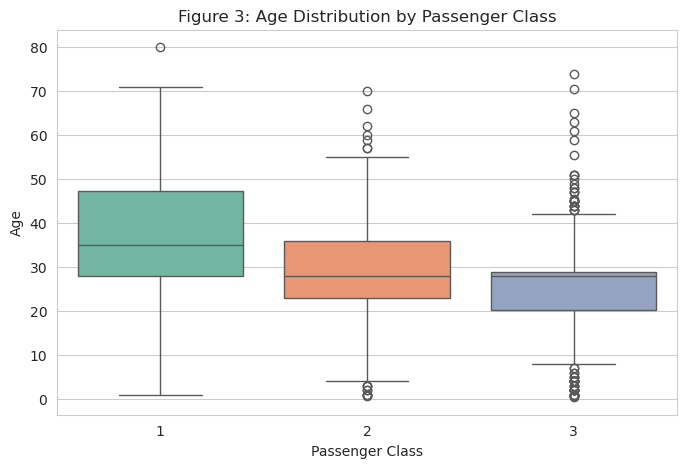

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Pclass", y="Age", data=clean_df, palette="Set2")

plt.title("Figure 3: Age Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age")

plt.show()

In [ ]:
### Interpretation

The boxplot indicates that passengers in **First Class** generally had higher ages than passengers in **Second** and **Third Class**. Several outliers are visible across the classes, representing unusually young or elderly passengers.

In [ ]:
## 4. Scatter Plot of Age versus Fare

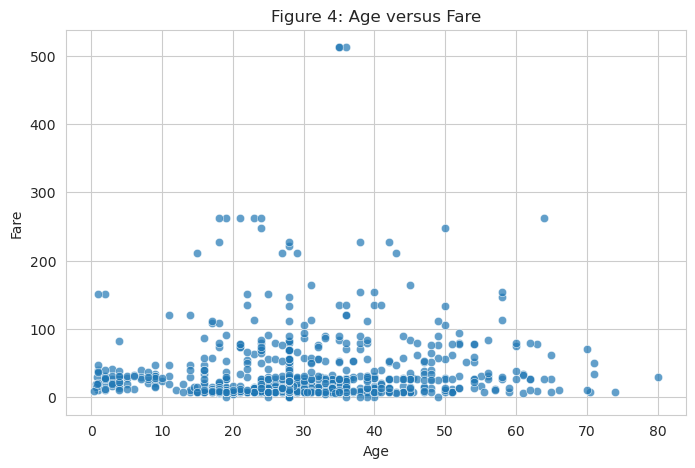

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=clean_df,
    x="Age",
    y="Fare",
    alpha=0.7
)

plt.title("Figure 4: Age versus Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

In [ ]:
### Interpretation

The scatter plot shows no strong linear relationship between passenger age and fare. However, several passengers paid exceptionally high fares, indicating the presence of outliers in the Fare variable.

In [ ]:
## 5. Correlation Heatmap

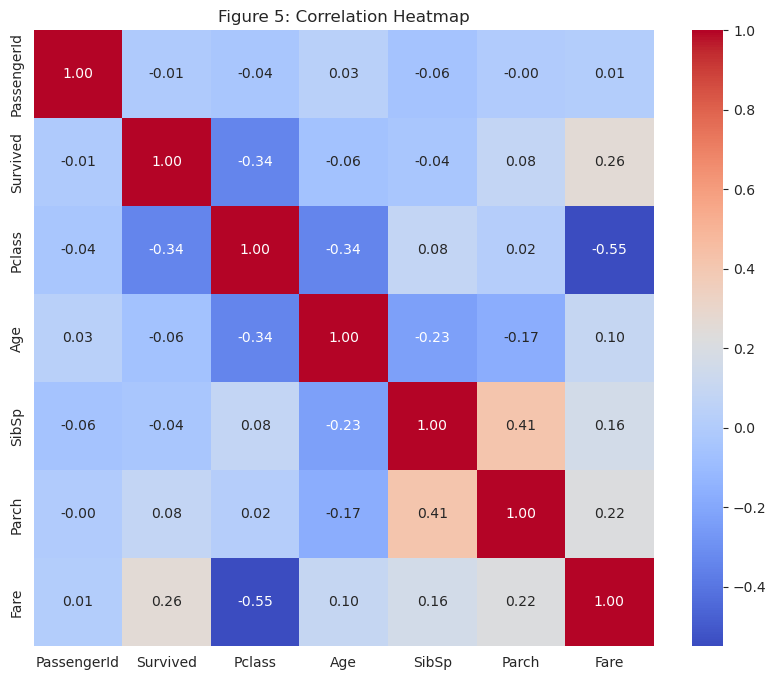

In [17]:
# Select numerical columns
numerical_data = clean_df.select_dtypes(include=['number'])

# Plot correlation heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    numerical_data.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Figure 5: Correlation Heatmap')

plt.show()

In [ ]:
### Interpretation

The correlation heatmap illustrates the strength and direction of relationships between numerical variables. The **Fare** variable shows a positive correlation with **Passenger Class (Pclass)**, while **Age** has relatively weak correlations with most other variables. The heatmap helps identify variables that may be useful for predictive modelling.

In [ ]:
## 6. Pairplot of Selected Numerical Variables

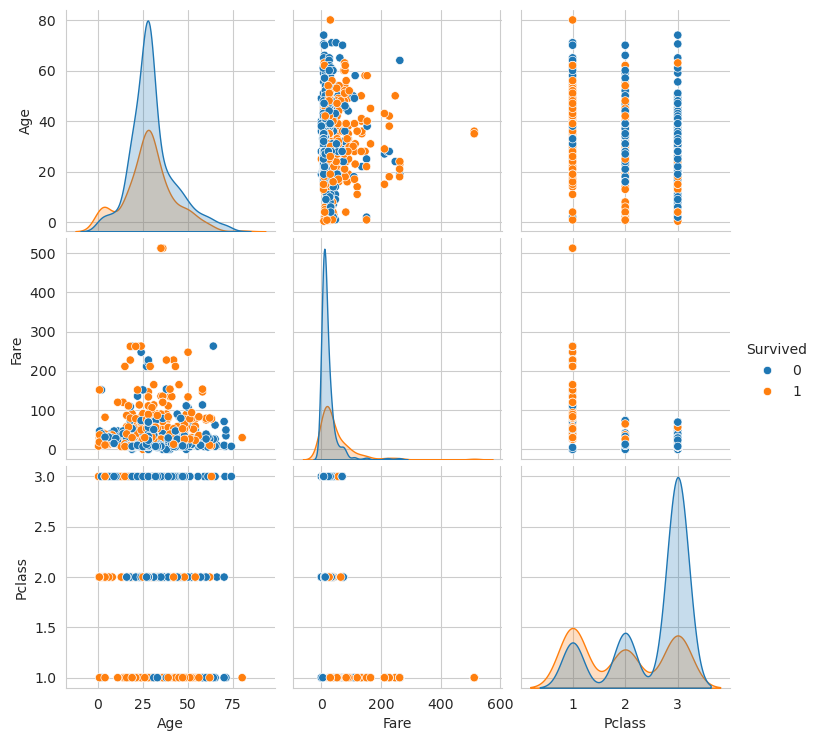

In [18]:
# Pairplot of selected numerical variables
sns.pairplot(
    clean_df[['Age', 'Fare', 'Pclass', 'Survived']],
    hue='Survived'
)

plt.show()

In [ ]:
### Interpretation

The pairplot provides a visual comparison of the relationships among Age, Fare, Passenger Class, and Survival. It shows that passengers who paid higher fares and travelled in higher classes generally had a greater likelihood of survival. The pairplot also highlights the distribution of each variable and potential relationships between them.

In [ ]:
# Question 4: Statistical Analysis

## 1. Descriptive Statistics

In [19]:
# Descriptive statistics for numerical variables
clean_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
### Interpretation

The descriptive statistics provide a summary of the numerical variables in the dataset. The average passenger age is approximately 29.7 years, while the average fare paid is about 32.20. The statistics also indicate considerable variation in fare values, suggesting the presence of high-value outliers.

In [ ]:
## 2. Frequency Distribution

In [20]:
# Frequency distribution of passenger survival
frequency = clean_df['Survived'].value_counts()

print(frequency)

Survived
0    549
1    342
Name: count, dtype: int64


In [ ]:
## 3. Correlation Analysis

In [21]:
# Correlation matrix
correlation_matrix = clean_df.select_dtypes(include='number').corr()

correlation_matrix

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


In [23]:
# Flatten the correlation matrix
corr_pairs = (
    correlation_matrix
    .where(~np.eye(correlation_matrix.shape[0], dtype=bool))
    .stack()
)

# Strongest positive correlation
strongest_positive = corr_pairs.idxmax()
positive_value = corr_pairs.max()

# Strongest negative correlation
strongest_negative = corr_pairs.idxmin()
negative_value = corr_pairs.min()

print("Strongest Positive Correlation:")
print(f"{strongest_positive} = {positive_value:.3f}")

print("\nStrongest Negative Correlation:")
print(f"{strongest_negative} = {negative_value:.3f}")

Strongest Positive Correlation:
('SibSp', 'Parch') = 0.415

Strongest Negative Correlation:
('Pclass', 'Fare') = -0.549


In [ ]:
## 4. Strongest Positive Correlation

The strongest positive correlation is between **SibSp** and **Parch**, with a correlation coefficient of **0.415**. This indicates a moderate positive relationship between the two variables.

In [ ]:
## 5. Strongest Negative Correlation

The strongest negative correlation is between **Pclass** and **Fare**, with a correlation coefficient of **-0.549**. This indicates that passengers travelling in higher classes generally paid higher fares.

In [ ]:
# Question 5: Machine Learning

## 1. Selecting Predictor Variables

In [24]:
# Create a copy of the cleaned dataset
ml_df = clean_df.copy()

# Convert categorical variables into numerical variables
ml_df = pd.get_dummies(
    ml_df,
    columns=['Sex', 'Embarked'],
    drop_first=True
)

# Remove columns that are not useful for prediction
ml_df = ml_df.drop(columns=['Name', 'Ticket'])

# Display first five rows
ml_df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,22.0,1,0,7.2500,True,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,35.0,0,0,8.0500,True,False,True


In [ ]:
## 2. Splitting the Dataset into Training and Testing Sets

In [25]:
# Predictor variables
X = ml_df.drop('Survived', axis=1)

# Target variable
y = ml_df['Survived']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (712, 9)
Testing Set : (179, 9)


In [ ]:
## 3. Training the Logistic Regression Classifier

In [27]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
model = LogisticRegression(random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression model trained successfully!


In [ ]:
## 4. Predicting the Testing Data

In [28]:
# Predict the testing data
y_pred = model.predict(X_test)

# Display the first 10 predictions
print(y_pred[:10])

[0 0 0 1 1 1 1 0 1 1]


In [ ]:
## 5. Model Accuracy

In [29]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7709


In [ ]:
## 6. Confusion Matrix

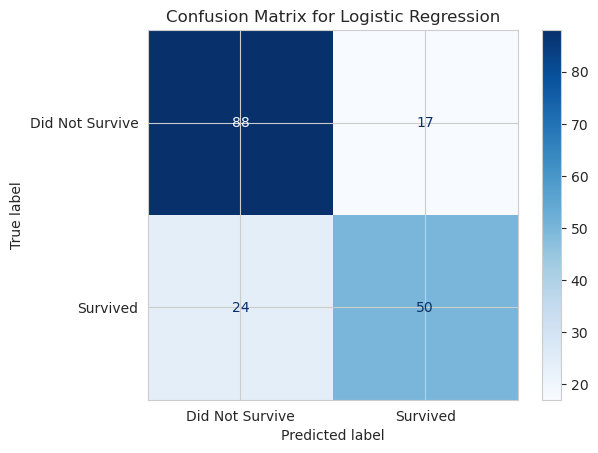

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did Not Survive", "Survived"]
)

display.plot(cmap="Blues")

plt.title("Confusion Matrix for Logistic Regression")

plt.show()

In [ ]:
## 7. Classification Report

In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.84      0.81       105
           1       0.75      0.68      0.71        74

    accuracy                           0.77       179
   macro avg       0.77      0.76      0.76       179
weighted avg       0.77      0.77      0.77       179



In [ ]:
## 8. Discussion of Model Performance

The Logistic Regression model achieved an overall **accuracy of 77%**, indicating that it correctly classified the survival status of most passengers in the testing dataset.

The classification report shows that the model performed better in predicting passengers who **did not survive** than those who **survived**. The model achieved a precision of **0.79** and recall of **0.84** for passengers who did not survive, while the precision and recall for passengers who survived were **0.75** and **0.68**, respectively.

Overall, the model demonstrates satisfactory performance for a binary classification problem. However, there is room for improvement, particularly in increasing the recall for the survival class. This could be achieved by applying feature engineering, hyperparameter tuning, or using more advanced machine learning algorithms.

In [ ]:
# Task 6: Discussion and Conclusion

In [ ]:
## Discussion

### Major Findings

The exploratory data analysis revealed several important factors that influenced passenger survival on the Titanic. Passenger class, gender, age, and fare were among the most significant variables associated with survival. Female passengers had a higher survival rate than male passengers, while passengers travelling in first class were more likely to survive than those travelling in second or third class. The analysis also showed that most passengers were between 20 and 40 years of age and that the majority of passengers travelled in third class.

### Statistical Insights

The statistical analysis provided additional understanding of the relationships between variables in the dataset. The strongest positive correlation was observed between **SibSp** and **Parch** (0.415), indicating that passengers travelling with siblings or spouses were also likely to be travelling with parents or children. The strongest negative correlation was found between **Passenger Class (Pclass)** and **Fare** (-0.549), showing that passengers travelling in higher classes generally paid higher ticket fares. Descriptive statistics also revealed substantial variation in passenger fares, suggesting the presence of outliers.

### Machine Learning Results

A Logistic Regression classifier was developed to predict passenger survival. Before training the model, missing values were handled appropriately, categorical variables were encoded, and numerical features were standardised. The model achieved an overall accuracy of **77%** on the testing dataset. The confusion matrix and classification report showed that the model performed better in predicting passengers who did not survive than those who survived. Although the model produced satisfactory results, its performance indicates that there is still potential for improvement.

In [ ]:
## Conclusion

This project successfully demonstrated the application of Python for exploratory data analysis, statistical analysis, and machine learning using the Titanic dataset. The analysis showed that passenger class, gender, age, and fare were important factors influencing passenger survival. Data cleaning techniques such as handling missing values and removing unnecessary variables improved the quality of the dataset before modelling.

The Logistic Regression classifier achieved satisfactory predictive performance with an accuracy of **77%**, showing that it can be used as a baseline model for predicting passenger survival. The project also demonstrated how data visualisation and statistical analysis can provide valuable insights that support decision-making and improve predictive modelling.

In [ ]:
## Limitations of the Study

- The dataset contains missing values that required preprocessing before analysis.
- Some potentially useful variables, such as detailed cabin information, contained a large number of missing values and were removed from the analysis.
- Logistic Regression assumes a linear relationship between the predictor variables and the outcome, which may limit its predictive performance.
- The dataset represents a historical event with a relatively small number of observations, which may limit the generalisability of the model to other datasets.

In [ ]:
## Recommendations

- Future studies should compare Logistic Regression with more advanced machine learning algorithms such as Random Forest, Decision Trees, Support Vector Machines, and Gradient Boosting.
- Additional feature engineering could be performed by creating new variables, such as family size or passenger title, to improve prediction accuracy.
- Hyperparameter tuning and cross-validation should be applied to optimise model performance.
- Larger and more diverse datasets should be considered to improve the robustness and generalisability of the predictive model.